<a href="https://colab.research.google.com/github/niafebrianty1702/Klasifikasi-Botol-dan-Box-Menggunakan-ResNet-18-Feature-Extraction/blob/main/ResNet18_Feature_Extraction_Botol_Box.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
import os

print("Daftar file di /content:")
print(os.listdir("/content"))

Daftar file di /content:
['.config', 'dataset.zip', 'sample_data']


In [ ]:
import zipfile
import os
import glob

# Mencari file ZIP di folder /content
zip_files = glob.glob("/content/*.zip")

if not zip_files:
    raise FileNotFoundError(
        "File ZIP belum ditemukan. Silakan upload dataset terlebih dahulu."
    )

# Menggunakan file ZIP pertama yang ditemukan
zip_path = zip_files[0]
extract_path = "/content/"

print("File ZIP:", zip_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak!")

File ZIP: /content/dataset.zip
Dataset berhasil diekstrak!


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    # Batasi kedalaman agar output tidak terlalu panjang
    depth = root.replace("/content", "").count(os.sep)

    if depth > 3:
        dirs[:] = []
        continue

    print(root)

/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/.config/logs/2026.09.30
/content/dataset
/content/dataset/train
/content/dataset/train/botol
/content/dataset/train/box
/content/dataset/botol
/content/dataset/box
/content/dataset/val
/content/dataset/val/botol
/content/dataset/val/box
/content/sample_data


In [ ]:
!pip install -q torch torchvision pandas matplotlib scikit-learn

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import time
import os

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=transform
)

print("Class:", train_dataset.classes)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Class: ['botol', 'box']
Train: 80
Validation: 20


In [ ]:
print(train_dataset.class_to_idx)

{'botol': 0, 'box': 1}


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

In [ ]:
weights = models.ResNet18_Weights.DEFAULT

resnet18 = models.resnet18(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


In [ ]:
for param in resnet18.parameters():
    param.requires_grad = False

In [ ]:
resnet18.fc

Linear(in_features=512, out_features=1000, bias=True)

In [ ]:
num_features = resnet18.fc.in_features

resnet18.fc = nn.Linear(
    num_features,
    2
)

In [ ]:
model = resnet18.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [ ]:
num_epochs = 15

In [ ]:
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total


    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/15] Train Loss: 0.6637 Train Acc: 58.75% Val Loss: 0.5965 Val Acc: 80.00%
Epoch [2/15] Train Loss: 0.4186 Train Acc: 87.50% Val Loss: 0.4210 Val Acc: 90.00%
Epoch [3/15] Train Loss: 0.3291 Train Acc: 91.25% Val Loss: 0.2088 Val Acc: 100.00%
Epoch [4/15] Train Loss: 0.1892 Train Acc: 100.00% Val Loss: 0.1547 Val Acc: 100.00%
Epoch [5/15] Train Loss: 0.1664 Train Acc: 98.75% Val Loss: 0.1319 Val Acc: 100.00%
Epoch [6/15] Train Loss: 0.1649 Train Acc: 97.50% Val Loss: 0.0902 Val Acc: 100.00%
Epoch [7/15] Train Loss: 0.1134 Train Acc: 98.75% Val Loss: 0.0794 Val Acc: 100.00%
Epoch [8/15] Train Loss: 0.0886 Train Acc: 100.00% Val Loss: 0.0630 Val Acc: 100.00%
Epoch [9/15] Train Loss: 0.0686 Train Acc: 100.00% Val Loss: 0.0545 Val Acc: 100.00%
Epoch [10/15] Train Loss: 0.0715 Train Acc: 100.00% Val Loss: 0.0497 Val Acc: 100.00%
Epoch [11/15] Train Loss: 0.0627 Train Acc: 100.00% Val Loss: 0.0434 Val Acc: 100.00%
Epoch [12/15] Train Loss: 0.0476 Train Acc: 100.00% Val Loss: 0.0394 Va

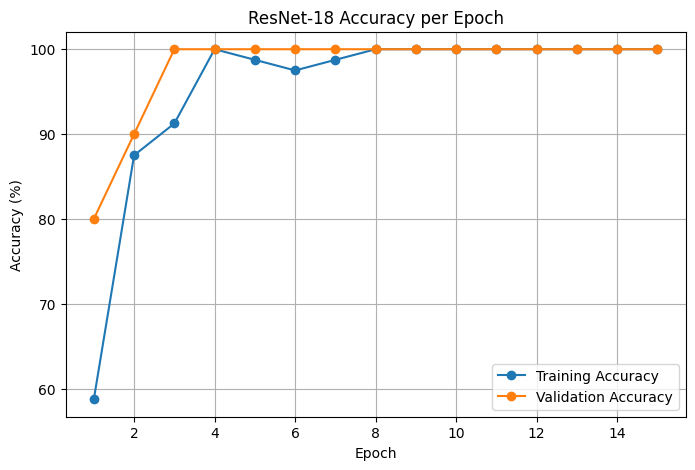

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, num_epochs + 1),
    train_accuracies,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    range(1, num_epochs + 1),
    val_accuracies,
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet-18 Accuracy per Epoch")
plt.legend()
plt.grid(True)

plt.show()

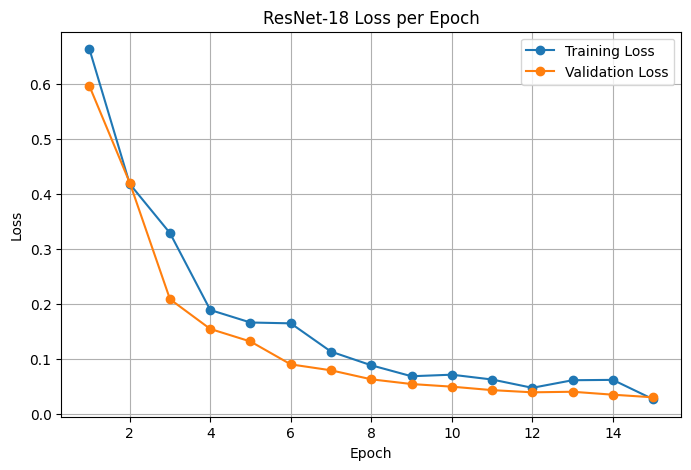

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker='o',
    label='Training Loss'
)

plt.plot(
    range(1, num_epochs + 1),
    val_losses,
    marker='o',
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-18 Loss per Epoch")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [ ]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Validation Accuracy: 100.00%


In [ ]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=train_dataset.classes
    )
)

              precision    recall  f1-score   support

       botol       1.00      1.00      1.00        10
         box       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



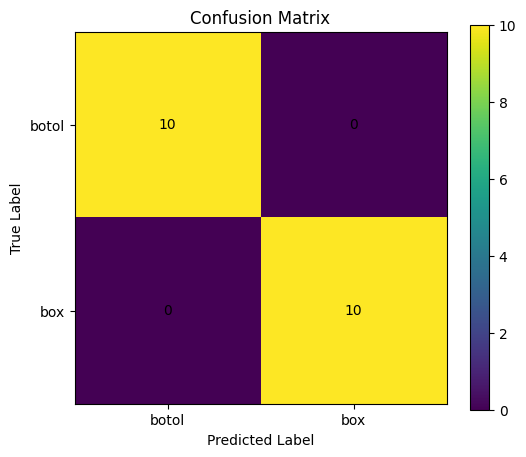

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(train_dataset.classes)),
    train_dataset.classes
)

plt.yticks(
    range(len(train_dataset.classes)),
    train_dataset.classes
)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [ ]:
model.eval()

dummy_input = torch.randn(
    1, 3, 224, 224
).to(device)

# Warm-up
with torch.no_grad():
    for _ in range(20):
        _ = model(dummy_input)

if device.type == "cuda":
    torch.cuda.synchronize()

start_time = time.perf_counter()

with torch.no_grad():
    for _ in range(100):
        _ = model(dummy_input)

if device.type == "cuda":
    torch.cuda.synchronize()

end_time = time.perf_counter()

total_time = end_time - start_time

latency_ms = (total_time / 100) * 1000

print(f"Average Latency: {latency_ms:.3f} ms")

Average Latency: 4.681 ms


In [ ]:
fps = 1000 / latency_ms

print(f"Average Latency: {latency_ms:.3f} ms")
print(f"Estimated FPS: {fps:.2f}")

Average Latency: 4.681 ms
Estimated FPS: 213.65


In [ ]:
from PIL import Image
import os
import pandas as pd

records = []

for split in ["train", "val"]:

    split_dir = f"/content/dataset/{split}"

    for class_name in os.listdir(split_dir):

        class_dir = os.path.join(
            split_dir,
            class_name
        )

        if not os.path.isdir(class_dir):
            continue

        for filename in os.listdir(class_dir):

            if filename.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):

                filepath = os.path.join(
                    class_dir,
                    filename
                )

                try:

                    img = Image.open(filepath)

                    width, height = img.size

                    records.append({
                        "filename": filename,
                        "class": class_name,
                        "split": split,
                        "width": width,
                        "height": height
                    })

                except:
                    pass

metadata = pd.DataFrame(records)

metadata.head()

,filename,class,split,width,height
0,0218100609.jpg,botol,train,200,150
1,0218100307.jpg,botol,train,200,150
2,0218102212.jpg,botol,train,200,150
3,0218092403.jpg,botol,train,200,150
4,0218102425.jpg,botol,train,200,150


In [ ]:
print("Jumlah data:", len(metadata))

Jumlah data: 100
